## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Important notes on logic in this notebook:
* Complaints dataset
    - removed complaints relating to credit bureaus given that they are out of scope of our research questions (removed 73.5% of data set)
    - removed incomplete zip codes (e.g. 32XXX) as they can not be connected to census data (14%)
* Merged data
    - removed zip codes with population <100. This resulted in removing 770 complaints (0.0003% of all non credit complaints)

## Load datasets

In [2]:
df_census = pd.read_csv("all_census_data.csv", index_col=0)

df_census['zcta'] = (
    df_census['zcta']
    .astype('Int64')      # allow NA if any
    .astype(str)
    .str.zfill(5)
)

df_census.head(5)

,zcta,minority_quintile,population_total,pct_white,pct_black_OR_african_american,pct_american_indian_OR_alaska_native,pct_asian,pct_native_hawaiian_OR_pacific_islander,pct_other_race,pct_two_or_more_races,...,income_cont,log_income_cont,pct_low_edu,pct_high_edu,income_cont_std,log_income_cont_std,pct_low_edu_std,pct_high_edu_std,income_zip_10k,share_bach_or_higher_zip
0,00601,5.0,17242,21.952210,3.352279,0.434984,0.034799,0.000000,19.475699,54.750029,...,14398.0,9.574845,35.058051,15.715968,-1.831469,-3.552473,2.371313,-0.551617,1.4398,0.157160
1,00602,5.0,37548,22.640354,3.957601,0.415468,0.061255,0.018643,24.904123,48.002557,...,16771.0,9.727406,34.160783,20.502354,-1.742648,-3.166127,2.280897,-0.274146,1.6771,0.205024
2,00603,5.0,49804,21.311541,4.162316,0.449763,0.110433,0.016063,26.831178,47.118705,...,15786.0,9.666879,26.990061,23.260691,-1.779517,-3.319407,1.558317,-0.114243,1.5786,0.232607
3,00606,5.0,5009,22.080256,7.666201,1.497305,0.199641,0.000000,30.425235,38.131364,...,14980.0,9.614471,45.108339,10.549354,-1.809685,-3.452123,3.384062,-0.851130,1.4980,0.105494
4,00610,5.0,25731,18.316428,5.720726,0.275932,0.027205,0.031091,24.204267,51.424352,...,20167.0,9.911803,31.741021,17.037574,-1.615537,-2.699162,2.037062,-0.475003,2.0167,0.170376


In [3]:
print(df_census['zcta'].dtype)                              # should be object
print(df_census['zcta'].astype(str).str.len().value_counts())  # ideally only 5

object
zcta
5    32923
Name: count, dtype: int64


In [4]:
df_complaints = pd.read_csv("complaints.csv", dtype={'ZIP code': 'string'})

df_complaints.head(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2020-07-06,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,346XX,NaN,Other,Web,2020-07-06,Closed with explanation,Yes,NaN,3730948
1,2025-10-06,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Investigation took more than 30 days,NaN,NaN,Experian Information Solutions Inc.,TX,75454,NaN,NaN,Web,2025-10-06,In progress,Yes,NaN,16372503
2,2025-10-14,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information is missing that should be on the r...,NaN,NaN,"EQUIFAX, INC.",TX,75062,NaN,NaN,Web,2025-10-14,In progress,Yes,NaN,16558024
3,2025-10-26,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,93619,NaN,NaN,Web,2025-10-26,In progress,Yes,NaN,16826857
4,2025-10-10,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"EQUIFAX, INC.",GA,30341,NaN,NaN,Web,2025-10-10,In progress,Yes,NaN,16507707


### filtering for non credit ones only
note: only taking into account complaints that don't come from credit bureaus

In [5]:
# List of credit bureaus to exclude
credit_bureaus = [
    'EQUIFAX, INC.',
    'TRANSUNION INTERMEDIATE HOLDINGS, INC.',
    'Experian Information Solutions Inc.'
]

# Filter the dataframe
df_noncredit_complaints = df_complaints[~df_complaints['Company'].isin(credit_bureaus)].copy()

In [6]:
df_noncredit_complaints = df_complaints[~df_complaints['Company'].isin(credit_bureaus)].copy()

# keep only 5 digit numeric ZIPs
zip_str = df_noncredit_complaints['ZIP code'].astype(str).str.strip()

df_noncredit_complaints = df_noncredit_complaints[
    zip_str.str.fullmatch(r'\d{5}')
].copy()

df_noncredit_complaints['ZIP code'] = (
    df_noncredit_complaints['ZIP code']
    .astype(str)
    .str.strip()
    .str.zfill(5)
)
df_noncredit_complaints.head(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
6,2025-10-14,Debt collection,I do not know,Took or threatened to take negative or legal a...,Threatened or suggested your credit would be d...,NaN,Company has responded to the consumer and the ...,"CITIBANK, N.A.",GA,30273,NaN,Consent not provided,Web,2025-10-14,Closed with non-monetary relief,Yes,NaN,16560622
9,2019-12-26,Credit card or prepaid card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...",Confusing or misleading advertising about the ...,NaN,NaN,CAPITAL ONE FINANCIAL CORPORATION,CA,94025,NaN,Consent not provided,Web,2019-12-26,Closed with explanation,Yes,NaN,3477549
23,2025-09-22,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,NaN,NaN,Synovus Bank,DC,20018,NaN,NaN,Web,2025-10-03,Closed with explanation,Yes,NaN,16107888
31,2025-10-16,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Investigation took more than 30 days,NaN,NaN,"CBC Companies, Inc.",NY,11580,NaN,NaN,Web,2025-10-16,Closed with explanation,Yes,NaN,16628087
32,2025-02-14,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,There are XXXX collections being reported to t...,Company believes it acted appropriately as aut...,"Lockhart, Morris & Montgomery Inc.",FL,33801,NaN,Consent provided,Web,2025-02-21,Closed with explanation,Yes,NaN,12085091


In [7]:
# Optional: check result
print(f"Remaining complaints (non-credit bureaus): {len(df_noncredit_complaints):,}")
print(f"This is {len(df_noncredit_complaints)/len(df_complaints)*100:.2f}% of original complaints")

Remaining complaints (non-credit bureaus): 2,687,909
This is 22.85% of original complaints


## Merge datasets


In [8]:
df_merged = pd.merge(
    df_census,
    df_noncredit_complaints,
    left_on='zcta',
    right_on='ZIP code',
    how='inner'
)

In [9]:
print(
    df_census['zcta'].astype(str).str.len().value_counts().head()
)
print(
    df_noncredit_complaints['ZIP code'].astype(str).str.len().value_counts().head()
)


zcta
5    32923
Name: count, dtype: int64
ZIP code
5    2687909
Name: count, dtype: int64


In [10]:
df_merged['Date received'] = pd.to_datetime(df_merged['Date received'])

df_merged['month'] = df_merged['Date received'].dt.to_period('M')

In [11]:
df_merged.columns

Index(['zcta', 'minority_quintile', 'population_total', 'pct_white',
       'pct_black_OR_african_american', 'pct_american_indian_OR_alaska_native',
       'pct_asian', 'pct_native_hawaiian_OR_pacific_islander',
       'pct_other_race', 'pct_two_or_more_races', 'pct_nonwhite',
       'median_income', 'mean_income', 'income_quintile', 'education_quintile',
       'pct_edu_less_9th', 'pct_edu_no_diploma', 'pct_edu_hs_grad',
       'pct_edu_some_college', 'pct_edu_assoc', 'pct_edu_bachelor',
       'pct_edu_grad_prof', 'pct_edu_hs_or_higher', 'pct_edu_bach_or_higher',
       'black_quintile', 'pct_black_native_other',
       'black_native_other_quintile', 'income_cont', 'log_income_cont',
       'pct_low_edu', 'pct_high_edu', 'income_cont_std', 'log_income_cont_std',
       'pct_low_edu_std', 'pct_high_edu_std', 'income_zip_10k',
       'share_bach_or_higher_zip', 'Date received', 'Product', 'Sub-product',
       'Issue', 'Sub-issue', 'Consumer complaint narrative',
       'Company public

In [12]:
grouped_df = (
    df_merged
    .groupby(['ZIP code', 'month', 'Company'])
    .agg(
        num_complaints=('Date received', 'count'),
        income_quintile=('income_quintile', 'mean'),
        minority_quintile=('minority_quintile','mean'),
        education_quintile=('education_quintile', 'mean'),
        population_total = ('population_total', 'mean'),
        income_zip_10k = ('income_zip_10k', 'mean'),
        share_bach_or_higher_zip = ('share_bach_or_higher_zip', 'mean'),
        black_quintile = ('black_quintile', 'mean'),
        black_native_other_quintile = ('black_native_other_quintile', 'mean'),
        
        
    )
    .reset_index()
    .sort_values(by='num_complaints', ascending=False)
)
grouped_df

,ZIP code,month,Company,num_complaints,income_quintile,minority_quintile,education_quintile,population_total,income_zip_10k,share_bach_or_higher_zip,black_quintile,black_native_other_quintile
934544,33071,2012-06,"BANK OF AMERICA, NATIONAL ASSOCIATION",196,5.0,5.0,5.0,40026.0,9.0849,0.434671,1.0,1.0
1469951,60620,2025-01,"Early Warning Services, LLC",87,1.0,5.0,3.0,66514.0,3.9499,0.182574,1.0,1.0
934571,33071,2012-06,Ocwen Financial Corporation,74,5.0,5.0,5.0,40026.0,9.0849,0.434671,1.0,1.0
1475988,60629,2025-01,"Early Warning Services, LLC",66,1.0,5.0,1.0,114453.0,4.3372,0.110897,1.0,1.0
1474980,60628,2025-01,"Block, Inc.",61,2.0,5.0,3.0,62832.0,4.4410,0.216936,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
827278,31410,2013-09,WELLS FARGO & COMPANY,1,5.0,3.0,5.0,23782.0,8.2622,0.483322,2.0,3.0
827277,31410,2013-08,WELLS FARGO & COMPANY,1,5.0,3.0,5.0,23782.0,8.2622,0.483322,2.0,3.0
827276,31410,2013-05,"BANK OF AMERICA, NATIONAL ASSOCIATION",1,5.0,3.0,5.0,23782.0,8.2622,0.483322,2.0,3.0
827275,31410,2013-01,UNITED SERVICES AUTOMOBILE ASSOCIATION,1,5.0,3.0,5.0,23782.0,8.2622,0.483322,2.0,3.0


In [13]:
grouped_df.to_csv("new_merged_aggregated.csv")

In [14]:
df_merged.describe()

,minority_quintile,population_total,pct_white,pct_black_OR_african_american,pct_american_indian_OR_alaska_native,pct_asian,pct_native_hawaiian_OR_pacific_islander,pct_other_race,pct_two_or_more_races,pct_nonwhite,...,pct_low_edu,pct_high_edu,income_cont_std,log_income_cont_std,pct_low_edu_std,pct_high_edu_std,income_zip_10k,share_bach_or_higher_zip,Date received,Complaint ID
count,2.650137e+06,2.650221e+06,2.650137e+06,2.650137e+06,2.650137e+06,2.650137e+06,2.650137e+06,2.650137e+06,2.650137e+06,2.650137e+06,...,2.649814e+06,2.649814e+06,2.646782e+06,2.646782e+06,2.649814e+06,2.649814e+06,2.646782e+06,2.649814e+06,2650221,2.650221e+06
mean,4.399589e+00,3.935499e+04,5.136342e+01,2.030177e+01,8.522425e-01,7.101361e+00,1.857789e-01,9.192325e+00,1.100310e+01,4.863658e+01,...,1.138598e+01,3.519036e+01,3.362779e-01,3.460545e-01,-1.407853e-02,5.773292e-01,7.231321e+00,3.519036e-01,2021-02-09 00:50:20.422523392,6.437608e+06
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,-2.092354e+00,-5.228495e+00,-1.161422e+00,-1.462685e+00,7.428000e-01,0.000000e+00,2011-12-01 00:00:00,1.000000e+00
25%,4.000000e+00,2.573800e+04,3.169262e+01,3.951242e+00,2.978024e-01,1.595354e+00,3.114518e-02,2.493075e+00,6.498952e+00,2.805080e+01,...,5.713368e+00,2.171979e+01,-4.391978e-01,-3.202891e-01,-5.856968e-01,-2.035705e-01,5.159500e+00,2.171979e-01,2017-12-25 00:00:00,2.763855e+06
50%,5.000000e+00,3.679400e+04,5.384048e+01,1.087608e+01,4.990473e-01,3.685875e+00,5.886104e-02,5.559989e+00,9.394373e+00,4.615952e+01,...,9.469947e+00,3.163234e+01,1.274500e-01,3.312701e-01,-2.071533e-01,3.710679e-01,6.673400e+00,3.163234e-01,2022-03-12 00:00:00,5.317581e+06
75%,5.000000e+00,5.091900e+04,7.194920e+01,2.800915e+01,9.644364e-01,8.605885e+00,1.289721e-01,1.178162e+01,1.354925e+01,6.830738e+01,...,1.494910e+01,4.628117e+01,9.150076e-01,1.025303e+00,3.449712e-01,1.220272e+00,8.777500e+00,4.628117e-01,2024-09-05 00:00:00,1.002981e+07
max,5.000000e+00,1.352560e+05,1.000000e+02,9.806835e+01,9.885823e+01,1.000000e+02,3.825088e+01,7.077206e+01,1.000000e+02,1.000000e+02,...,1.000000e+02,1.000000e+02,6.897354e+00,3.651533e+00,8.915394e+00,4.334397e+00,2.476040e+01,1.000000e+00,2025-11-01 00:00:00,1.696439e+07
std,8.370472e-01,2.022866e+04,2.464251e+01,2.291309e+01,1.967746e+00,9.476915e+00,6.790476e-01,9.867938e+00,7.049119e+00,2.464251e+01,...,7.813118e+00,1.735811e+01,1.076266e+00,9.793759e-01,7.873136e-01,1.006264e+00,2.875437e+00,1.735811e-01,NaN,4.573463e+06


### Normalization of complaints per population
note: this is going to normalize complaitns total over time based on 2020 population

Removing zip codes of population under 100. We found these are often zip codes tied to inhabited areas such as police police stations or airports. 

These zip codes had complaints attributed to them, but we think those were zip codes where people were submitting forms rather than where they lived. This makes it unusable for our research question. 

We confirmed this makes up a very low (0.0003) percentage of all complaitns.

In [15]:
# Calculate complaints per zip code normalized by population
complaints_per_zip = df_merged.groupby('zcta').agg({
    'Complaint ID': 'count',
    'population_total': 'first',
    'minority_quintile': 'first',
    'income_quintile': 'first',
    'education_quintile': 'first'
}).reset_index()

complaints_per_zip.columns = ['zcta', 'complaint_count', 'population', 
                               'minority_quintile', 'income_quintile', 'education_quintile']

# Check for population under 100
low_pop_zips = complaints_per_zip[complaints_per_zip['population'] <= 100]
low_pop_count = len(low_pop_zips)
low_pop_complaints = low_pop_zips['complaint_count'].sum()

print(f"Zip codes with zero population: {low_pop_count}")
print(f"% of all zip codes: {low_pop_count/len(complaints_per_zip):.3f}%")
print(f"Complaints excluded due to zero population: {low_pop_complaints}")
print(f"% of all non credit complaints: {low_pop_complaints/len(df_noncredit_complaints):.4f}%")

# Remove zip codes with <100 population
complaints_per_zip = complaints_per_zip[complaints_per_zip['population'] > 1000].copy()

# Calculate complaints per 10,000 residents
complaints_per_zip['complaints_per_10k'] = (
    complaints_per_zip['complaint_count'] / complaints_per_zip['population'] * 10000
)

print("\nSummary of complaints per 10K:")
print(complaints_per_zip['complaints_per_10k'].describe())

Zip codes with zero population: 275
% of all zip codes: 0.011%
Complaints excluded due to zero population: 770
% of all non credit complaints: 0.0003%

Summary of complaints per 10K:
count    21817.000000
mean        49.698768
std         51.077349
min          0.707914
25%         16.607509
50%         32.686022
75%         65.574920
max        860.769536
Name: complaints_per_10k, dtype: float64


## EDA

### Normalized Zip Codes

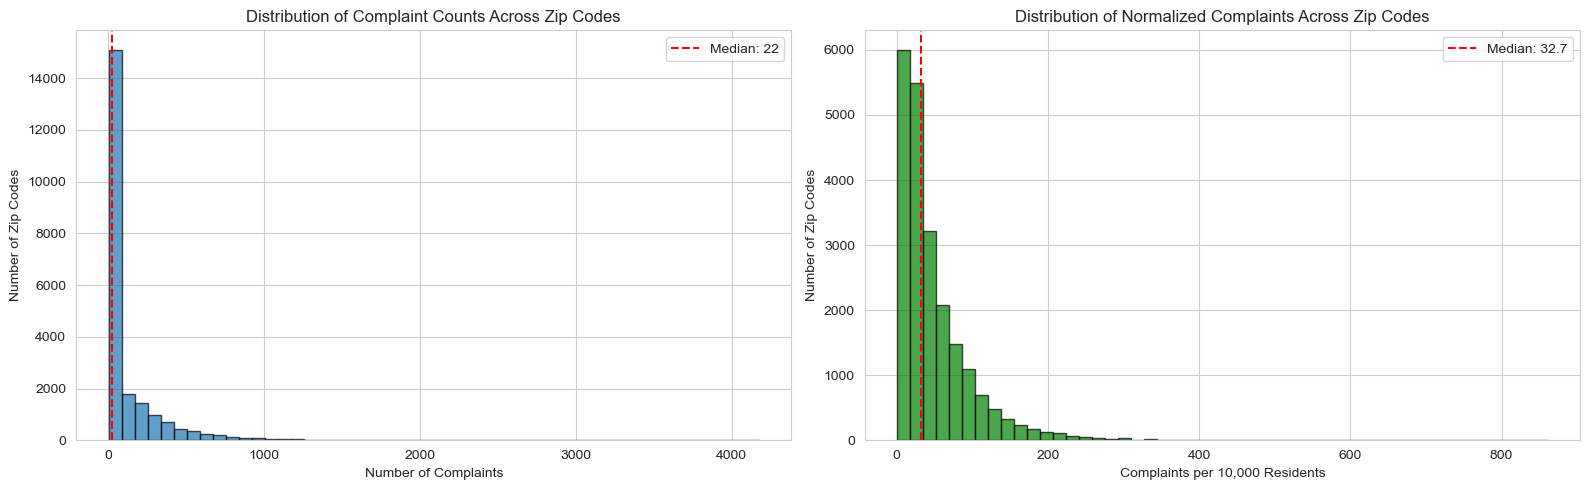

In [16]:
# Histogram of complaint counts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Raw complaint counts
axes[0].hist(complaints_per_zip['complaint_count'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Complaints')
axes[0].set_ylabel('Number of Zip Codes')
axes[0].set_title('Distribution of Complaint Counts Across Zip Codes')
axes[0].axvline(complaints_per_zip['complaint_count'].median(), 
                color='red', linestyle='--', label=f'Median: {complaints_per_zip["complaint_count"].median():.0f}')
axes[0].legend()

# Complaints per 10K (normalized)
axes[1].hist(complaints_per_zip['complaints_per_10k'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Complaints per 10,000 Residents')
axes[1].set_ylabel('Number of Zip Codes')
axes[1].set_title('Distribution of Normalized Complaints Across Zip Codes')
axes[1].axvline(complaints_per_zip['complaints_per_10k'].median(), 
                color='red', linestyle='--', label=f'Median: {complaints_per_zip["complaints_per_10k"].median():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

- Complaint intensity is **highly right-skewed**, with most ZIPs showing moderate rates and a small tail exceeding 500 complaints per 10k residents.
- This skew suggests **geographic clustering of consumer frictions**, possibly reflecting local differences in financial access, economic stress, or consumer awareness.

In [17]:
# Top zip codes by normalized complaint count
print("="*80)
print("TOP 10 ZIP CODES BY NORMALIZED NUMBER OF COMPLAINTS")
print("="*80)
top_zips_count = complaints_per_zip.nlargest(10, 'complaints_per_10k')[
    ['zcta', 'complaint_count', 'population', 'complaints_per_10k', 
     'minority_quintile', 'income_quintile', 'education_quintile']
]
print(top_zips_count.to_string(index=False))

TOP 10 ZIP CODES BY NORMALIZED NUMBER OF COMPLAINTS
 zcta  complaint_count  population  complaints_per_10k  minority_quintile  income_quintile  education_quintile
39739              217        2521          860.769536                5.0              1.0                 1.0
30326              601        8729          688.509566                4.0              5.0                 5.0
30349             4175       81320          513.403837                5.0              2.0                 4.0
30038             2176       43683          498.134286                5.0              2.0                 4.0
30331             2997       60770          493.170973                5.0              2.0                 4.0
39341              322        6607          487.361889                5.0              1.0                 2.0
30213             2046       42518          481.207959                5.0              4.0                 4.0
60443             1010       21309          473.978131      

### Top Zip Codes on map

In [18]:
# !pip install folium pgeocode

import folium
from folium.plugins import MarkerCluster
import pgeocode

# Your ZIP codes
zips = top_zips_count["zcta"].astype(str).tolist()
# Get coordinates for ZIPs
nomi = pgeocode.Nominatim('us')
df = nomi.query_postal_code(zips)
df = df[(df.latitude.notna()) & (df.longitude.notna())]

# Create folium map centered on average lat/lon
center = [df.latitude.mean(), df.longitude.mean()]
m = folium.Map(location=center, zoom_start=6)
cluster = MarkerCluster().add_to(m)

# Add circle markers
for _, r in df.iterrows():
    folium.CircleMarker(
        location=[r.latitude, r.longitude],
        radius=6,
        fill=True,
        fill_color="blue",
        popup=f"ZIP: {r.postal_code}<br>{r.place_name}, {r.state_code}"
    ).add_to(cluster)

m

The ZIP codes with the highest complaint rates per 10,000 residents share several socioeconomic characteristics:

- Nearly all fall within the **highest minority quintile (Q5)**, confirming that complaint intensity is strongly associated with areas of higher minority concentration.  
- Most of these ZIPs are in the **middle-to-upper education quintiles (Q4–Q5)**, suggesting that education level may amplify the likelihood of reporting or awareness of formal complaint mechanisms.  

In [19]:
# Function to analyze complaints per 10K by quintile
def analyze_by_quintile(df_zip, quintile_col, quintile_name):
    summary = df_zip.groupby(quintile_col).agg({
        'complaints_per_10k': ['mean', 'median', 'std', 'min', 'max'],
        'zcta': 'count'
    }).round(2)
    
    summary.columns = ['Mean', 'Median', 'Std Dev', 'Min', 'Max', 'N Zip Codes']
    
    print(f"\n{'='*60}")
    print(f"Complaints per 10K by {quintile_name}")
    print(f"{'='*60}")
    print(summary)
    
    return summary

# Analyze by each quintile type
minority_summary = analyze_by_quintile(complaints_per_zip, 'minority_quintile', 'Minority Quintile')
income_summary = analyze_by_quintile(complaints_per_zip, 'income_quintile', 'Income Quintile')
education_summary = analyze_by_quintile(complaints_per_zip, 'education_quintile', 'Education Quintile')


Complaints per 10K by Minority Quintile
                    Mean  Median  Std Dev   Min     Max  N Zip Codes
minority_quintile                                                   
1.0                17.15   14.01    13.56  1.30  153.47         2679
2.0                23.64   19.87    17.34  1.42  391.03         3997
3.0                36.44   30.86    25.61  0.71  447.84         4551
4.0                57.16   47.54    43.18  0.82  688.51         5241
5.0                89.43   74.61    71.55  1.25  860.77         5349

Complaints per 10K by Income Quintile
                  Mean  Median  Std Dev   Min     Max  N Zip Codes
income_quintile                                                   
1.0              46.29   28.06    53.32  0.71  860.77         3696
2.0              41.27   24.02    51.07  1.22  513.40         4181
3.0              43.18   26.34    47.87  1.16  451.55         4228
4.0              49.52   32.43    50.69  1.30  481.21         4461
5.0              65.41   53.94    4

Analyzing complaint rates by quintiles shows clear heterogeneity:

- **Minority quintile:** Complaint intensity rises almost linearly, from ~17 per 10k in low-minority ZIPs to nearly 90 in the top quintile.  
  This pattern implies that **racial composition is a strong predictor** of complaint activity, potentially linked to historical financial exclusion or targeting by high-fee services.

- **Income quintile:** Complaint rates increase from ~46 to ~65 per 10k from lowest to highest income areas.  
  The rise at the top may reflect **higher financial participation**, i.e., wealthier households interact with more products and thus have more opportunities for disputes as well as more understanding and greater financial literacy.

- **Education quintile:** Higher-education ZIPs show more complaints (~71 per 10k) than less educated ones (~33 per 10k).  
  This likely indicates **greater financial literacy and awareness of consumer rights**, leading to higher reporting rather than higher misconduct.


### Complaint Products by Quintiles

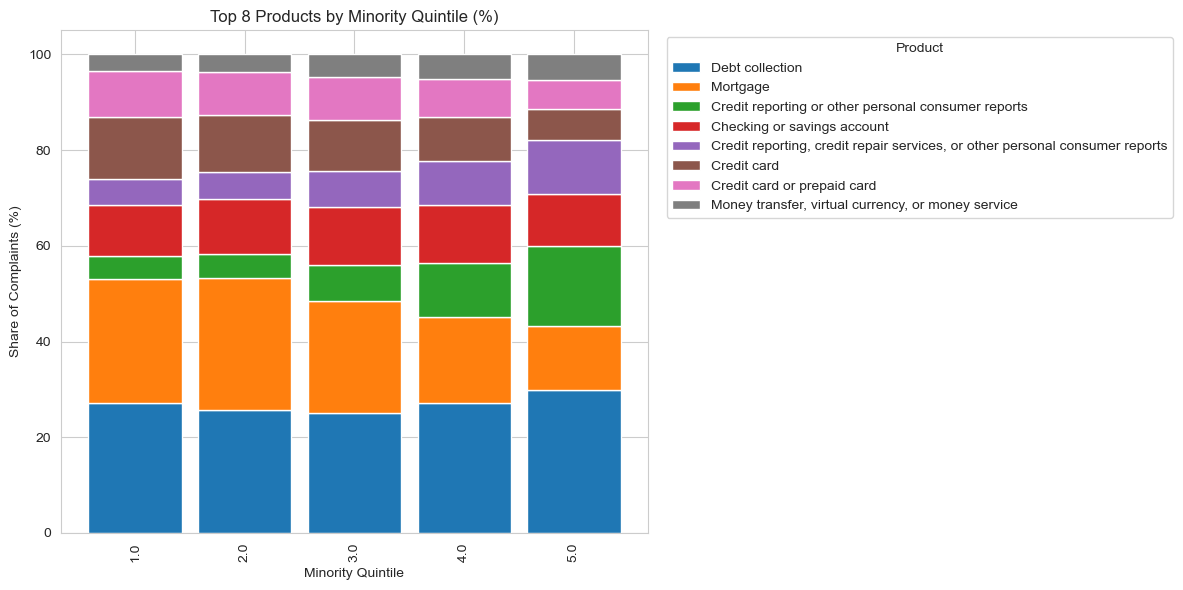

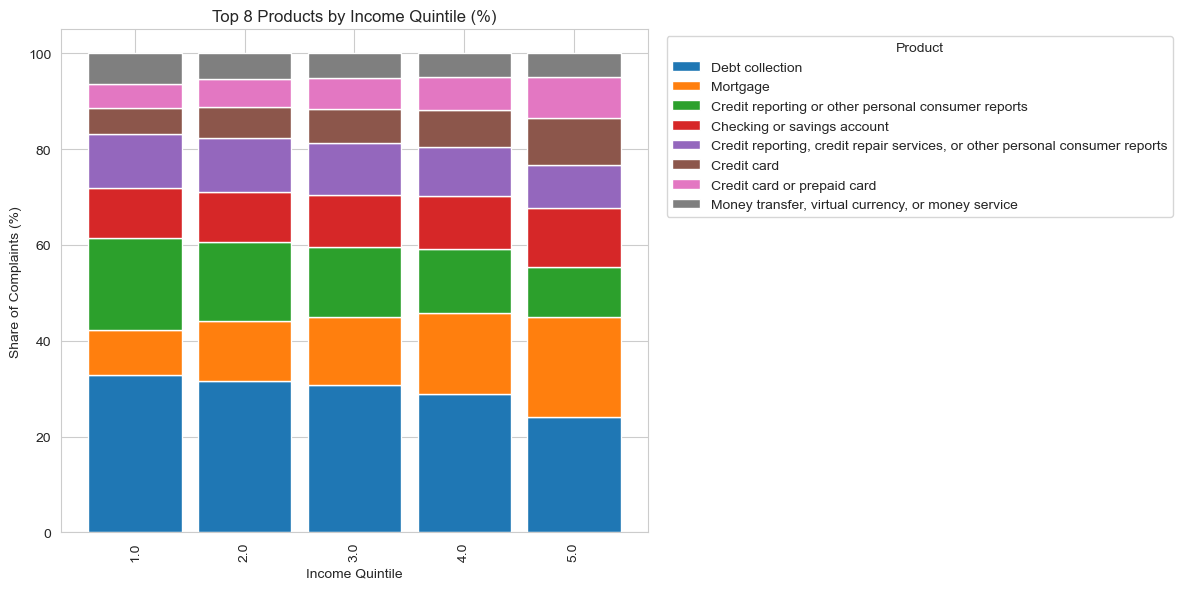

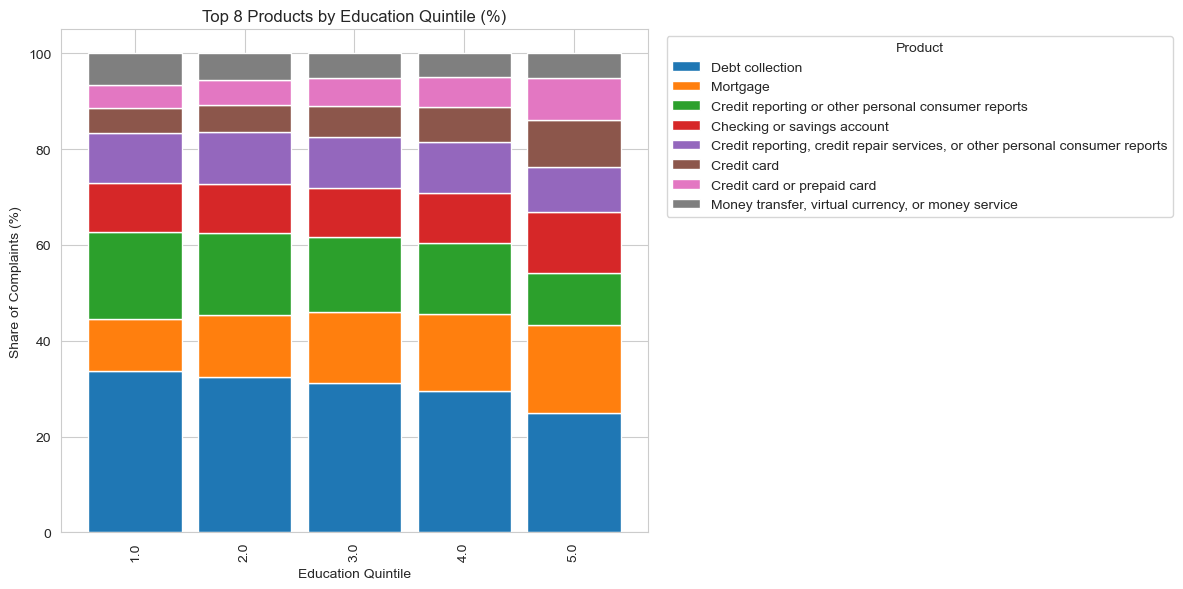

In [20]:
# === 1A. Stacked bar: Top products by quintile (minority, income, education) ===
def stacked_share_plot(df, group_col, cat_col, title, top=8, width=0.85):
    # Limit to top categories overall
    cats = df[cat_col].value_counts().head(top).index
    df_top = df[df[cat_col].isin(cats)].copy()
    df_top[group_col] = pd.Categorical(df_top[group_col], categories=sorted(df_top[group_col].dropna().unique()), ordered=True)

    share = (pd.crosstab(df_top[group_col], df_top[cat_col], normalize='index') * 100)[cats]
    ax = share.plot(kind='bar', stacked=True, figsize=(12,6), width=width)
    ax.set_title(title)
    ax.set_xlabel(group_col.replace('_', ' ').title())
    ax.set_ylabel('Share of Complaints (%)')
    ax.legend(title=cat_col, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Product (Top 8), by each quintile dimension
stacked_share_plot(df_merged, 'minority_quintile', 'Product', 'Top 8 Products by Minority Quintile (%)')
stacked_share_plot(df_merged, 'income_quintile',   'Product', 'Top 8 Products by Income Quintile (%)')
stacked_share_plot(df_merged, 'education_quintile','Product', 'Top 8 Products by Education Quintile (%)')


Across all three quintile dimensions, the **relative mix of complaint types** remains stable — but notable shifts appear:

- **Debt collection** dominates across all groups, but **checking/savings** and **credit card** complaints rise in higher-income or more educated ZIPs.
- **Money transfer and virtual currency** complaints also grow with education quintile, consistent with more digital engagement.
- In contrast, **mortgage and loan-related issues** remain prevalent in low-income and high-minority areas.

These results suggest **financial product usage diversity** increases with socioeconomic status, but **complaint concentration in debt collection** persists as a universal source of friction.


KeyboardInterrupt: 

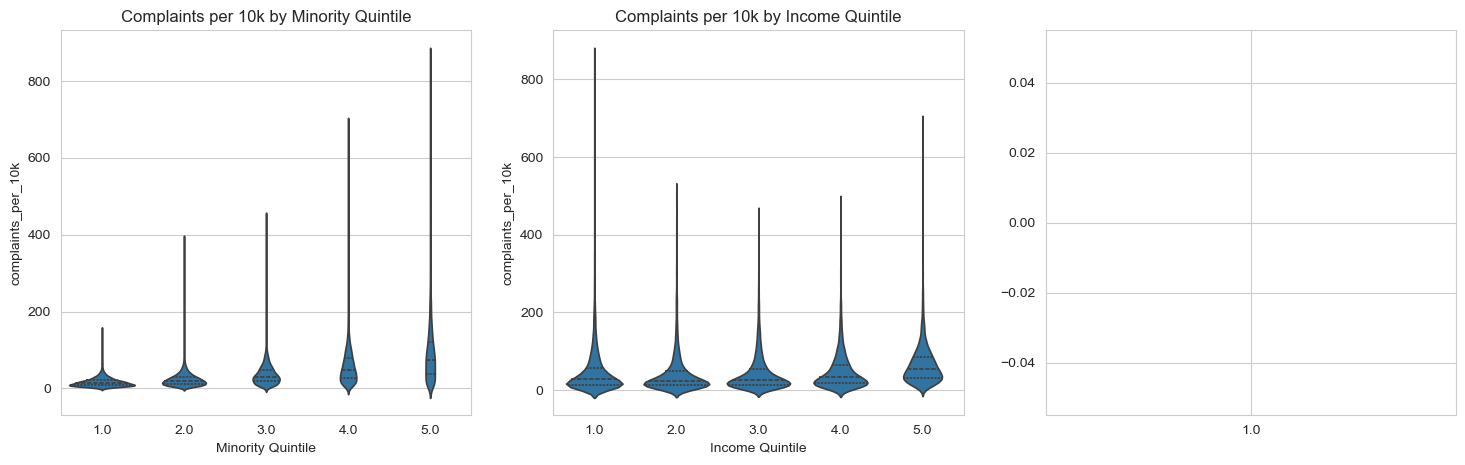

In [21]:
# === 2. Violin/boxen plots of complaints_per_10k by quintile ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.violinplot(data=complaints_per_zip, x='minority_quintile', y='complaints_per_10k', inner='quartile', ax=axes[0])
axes[0].set_title('Complaints per 10k by Minority Quintile'); axes[0].set_xlabel('Minority Quintile')

sns.violinplot(data=complaints_per_zip, x='income_quintile', y='complaints_per_10k', inner='quartile', ax=axes[1])
axes[1].set_title('Complaints per 10k by Income Quintile'); axes[1].set_xlabel('Income Quintile')

sns.violinplot(data=complaints_per_zip, x='education_quintile', y='complaints_per_10k', inner='quartile', ax=axes[2])
axes[2].set_title('Complaints per 10k by Education Quintile'); axes[2].set_xlabel('Education Quintile')

for ax in axes: 
    ax.set_ylabel('Complaints per 10k')
plt.tight_layout(); plt.show()


The violin plots reinforce the presence of **systematic dispersion** across quintiles:
- Minority quintiles show a much wider and higher distribution tail.
- Education and income quintiles exhibit narrower distributions, but both trend upward with higher quintile values.
- The overlap across middle quintiles indicates that socioeconomic factors interact — not all low-income ZIPs experience low complaint intensity.

Overall, **minority share** emerges as the most differentiating dimension, followed by education. Income alone explains less variation.

### OLS

In [ ]:
# === Categorical OLS: complaint intensity vs. quintile categories ===

import statsmodels.formula.api as smf

# Prepare data
cpz = complaints_per_zip.dropna(
    subset=['complaints_per_10k', 'minority_quintile', 'income_quintile', 'education_quintile']
).copy()

# Ensure numeric type for the categorical variables (1–5)
for c in ['minority_quintile', 'income_quintile', 'education_quintile']:
    cpz[c] = pd.to_numeric(cpz[c], errors='coerce')

# Estimate OLS with categorical dummies
model_cat = smf.ols(
    formula="""
        complaints_per_10k ~ 
        C(minority_quintile) + 
        C(income_quintile) + 
        C(education_quintile)
    """,
    data=cpz
).fit(cov_type='HC1')  # robust SEs (HC1 = heteroskedasticity-consistent)

print(model_cat.summary())


                            OLS Regression Results                            
Dep. Variable:     complaints_per_10k   R-squared:                       0.350
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     901.4
Date:                Wed, 26 Nov 2025   Prob (F-statistic):               0.00
Time:                        14:14:39   Log-Likelihood:            -1.1112e+05
No. Observations:               21636   AIC:                         2.223e+05
Df Residuals:                   21623   BIC:                         2.224e+05
Df Model:                          12                                         
Covariance Type:                  HC1                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

OLS results (R² ≈ 0.35) indicate:
- Strong, statistically significant effects for all quintiles, with **minority** and **education** quintiles showing the largest positive coefficients.
- Compared to the lowest groups, top minority quintiles (Q4–Q5) correspond to **+30–70 additional complaints per 10k residents**, controlling for income and education.
- Higher education quintiles (Q4–Q5) also associate with +25–36 per 10k.
- Income effects are positive but modest (~+9 per 10k from bottom to top quintile).

### Pairwise heterogeneity heatmaps

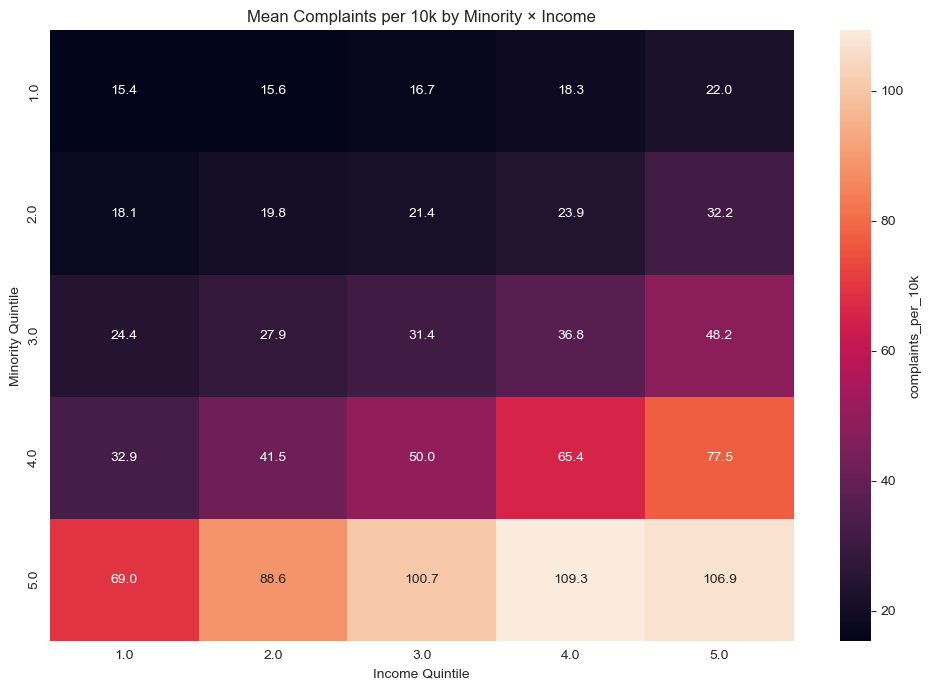

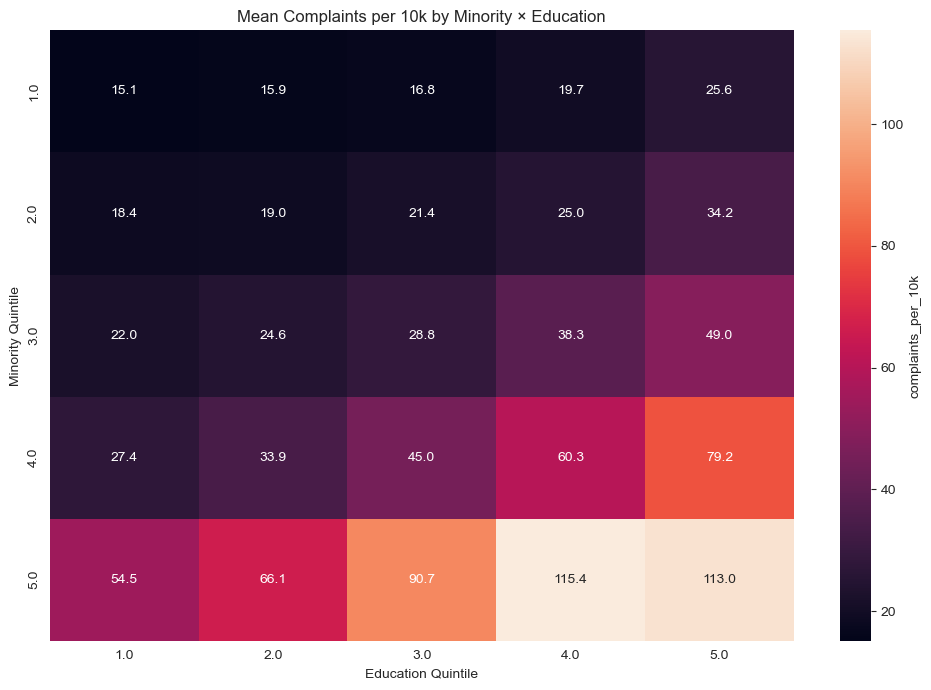

In [ ]:
# === 4. Heatmaps for pairwise heterogeneity ===
def heatmap_pair(df, idx, col, val, title):
    pivot = df.pivot_table(values=val, index=idx, columns=col, aggfunc='mean')
    plt.figure(figsize=(10,7))
    sns.heatmap(pivot, annot=True, fmt='.1f', cbar_kws={'label': val})
    plt.title(title); plt.xlabel(col.replace('_',' ').title()); plt.ylabel(idx.replace('_',' ').title())
    plt.tight_layout(); plt.show()

heatmap_pair(complaints_per_zip, 'minority_quintile', 'income_quintile', 'complaints_per_10k',
             'Mean Complaints per 10k by Minority × Income')

heatmap_pair(complaints_per_zip, 'minority_quintile', 'education_quintile', 'complaints_per_10k',
             'Mean Complaints per 10k by Minority × Education')


The heatmaps highlight **joint patterns** between demographic and socioeconomic factors:

- Complaint intensity **rises strongly along both the minority and education axes**.
- Within the highest minority quintile (Q5), ZIPs in the top education quintile (Q5) show roughly **double** the complaint rate of those in the lowest education quintile — indicating that **education amplifies reporting behavior** even in highly minority areas.
- Similarly, higher income also increases complaint intensity, but the effect is less pronounced than that of education.
- These patterns suggest that **awareness and capacity to act (education)** mediate the relationship between minority concentration and consumer complaint activity.


### Time series

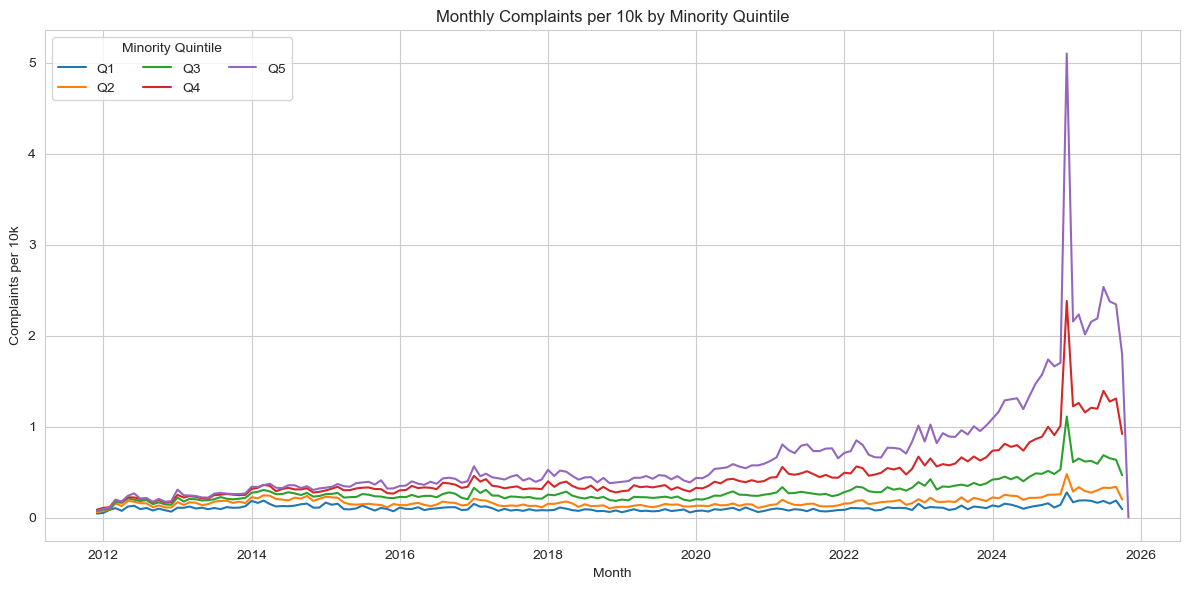

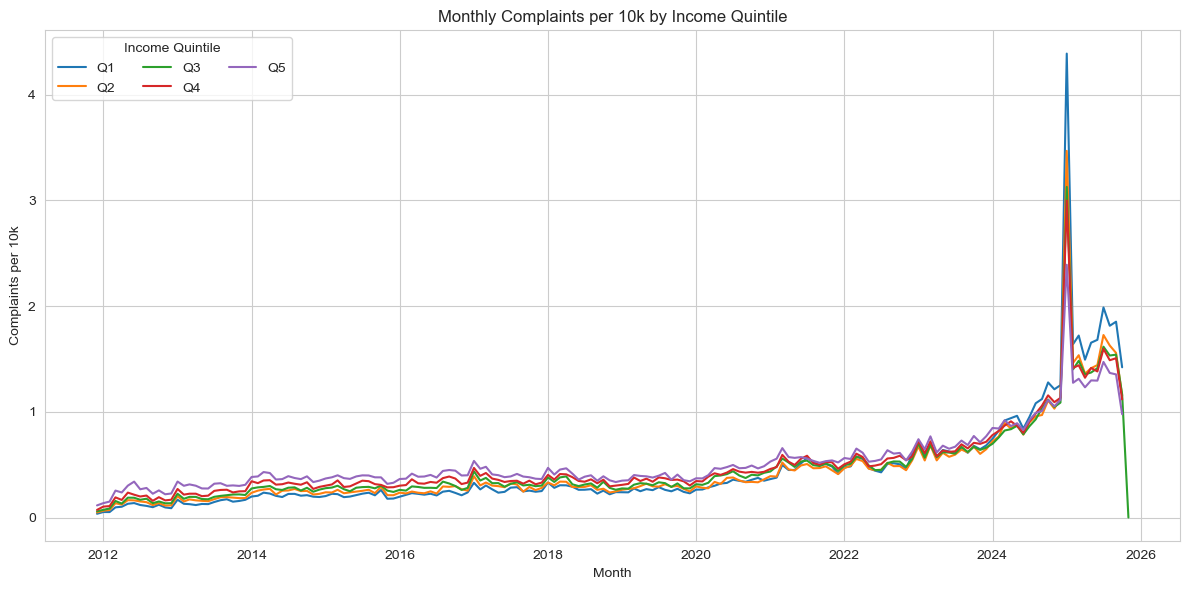

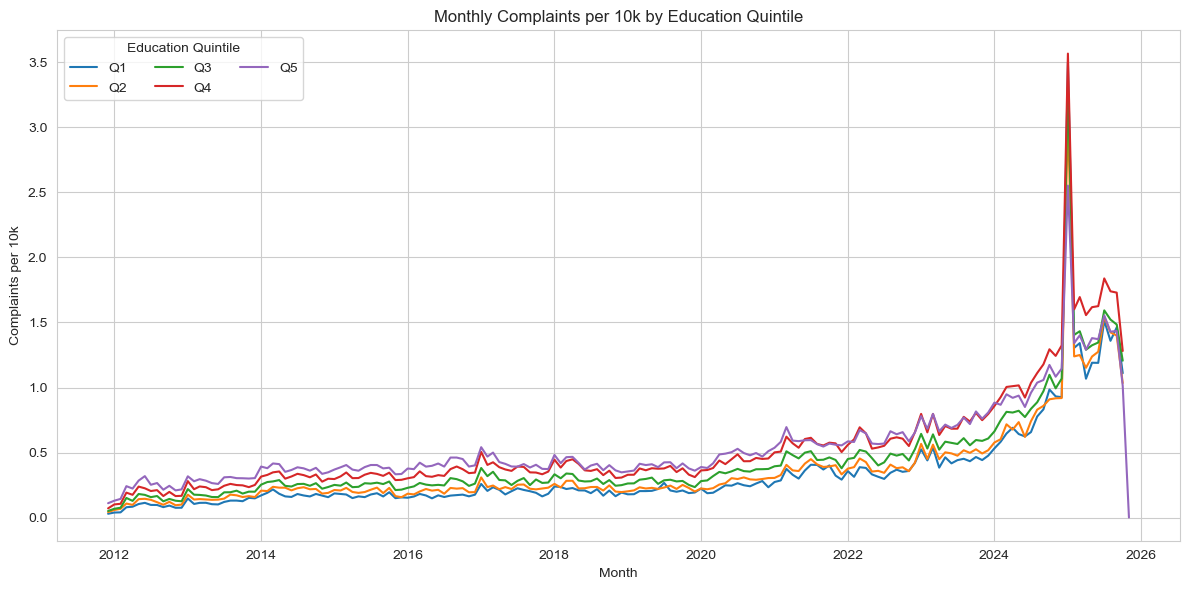

In [ ]:
# Base data: one row per complaint with its ZIP's quintiles
dts = df_merged[['zcta','Date received']].copy()
dts['Date received'] = pd.to_datetime(dts['Date received'], errors='coerce')
dts = dts.dropna(subset=['Date received'])

# Attach quintiles + population once
pop_q = complaints_per_zip[['zcta','population','minority_quintile','income_quintile','education_quintile']]
dts = dts.merge(pop_q, on='zcta', how='left').dropna(subset=['population'])

def make_trend_plot(quintile_col: str, title_suffix: str):
    # Fixed population per quintile (avoids double-counting population)
    pop_by_q = (complaints_per_zip
                .groupby(quintile_col, as_index=False)['population']
                .sum()
                .rename(columns={'population': 'population_q'}))

    # Monthly complaint counts per quintile
    monthly = (
        dts.assign(month=lambda x: x['Date received'].dt.to_period('M').dt.to_timestamp())
           .groupby(['month', quintile_col], as_index=False)
           .agg(complaints=('zcta', 'size'))
           .merge(pop_by_q, on=quintile_col, how='left')
    )
    monthly['complaints_per_10k'] = 1e4 * monthly['complaints'] / monthly['population_q']

    # Plot — same style as your original
    plt.figure(figsize=(12, 6))
    for q, g in monthly.groupby(quintile_col):
        g_sorted = g.sort_values('month')
        plt.plot(g_sorted['month'], g_sorted['complaints_per_10k'], label=f'Q{int(q)}')
    plt.title(f'Monthly Complaints per 10k by {title_suffix}')
    plt.xlabel('Month'); plt.ylabel('Complaints per 10k')
    plt.legend(title=title_suffix, ncol=3)
    plt.tight_layout()
    plt.show()

# Make the three figures
make_trend_plot('minority_quintile', 'Minority Quintile')
make_trend_plot('income_quintile', 'Income Quintile')
make_trend_plot('education_quintile', 'Education Quintile')


- All quintiles show similar trajectories up to ~2019, with a marked **acceleration post-2020**, aligning with pandemic-related financial stress and digital complaint expansion.